***Ejercicio 2:***

***Construcción de una Red Neuronal Convolucional (CNN) para Clasificación de Imágenes Usando Keras***

**Objetivo:**

En este ejercicio, implementarás una Red Neuronal Convolucional (CNN) utilizando la librería Keras para clasificar imágenes del conjunto de datos CIFAR-10. Este conjunto de datos consta de 60,000 imágenes de 32x32 píxeles a color, distribuidas en 10 clases diferentes. Al finalizar el ejercicio, comprenderás cómo construir, entrenar y evaluar un modelo de CNN utilizando Keras.

**Pasos:**

1. Preparación del Conjunto de Datos: Cargarás el conjunto de datos CIFAR-10, que está incluido en Keras, y lo preprocesarás normalizando los valores de los píxeles y convirtiendo las etiquetas a formato categórico.
2. Arquitectura del Modelo: Crearás un modelo de CNN con múltiples capas convolucionales, capas de pooling (submuestreo) y capas fully connected. El objetivo es crear un modelo capaz de extraer jerarquías espaciales de características a partir de las imágenes.
3. Compilación del Modelo: Compilarás el modelo utilizando una función de pérdida, un optimizador y una métrica de rendimiento adecuados.
4. Entrenamiento del Modelo: Entrenarás el modelo con los datos de entrenamiento de CIFAR-10 y lo validarás utilizando una parte de los datos.
5. Evaluación del Modelo: Evaluarás el modelo en el conjunto de datos de prueba y medirás su precisión.

**Requisitos:**

- Entorno de Python 3.x
- Keras y TensorFlow instalados (pip install keras tensorflow)
- Comprensión básica de Python y Redes Neuronales

**Tareas:**

1. Cargar y Preprocesar el Conjunto de Datos CIFAR-10
- Normalizar los datos de imagen escalando los valores de los píxeles entre 0 y 1.
- Convertir las etiquetas en formato categórico para clasificación multiclase.
2. Definir la Arquitectura de la CNN
- Utilizar capas convolucionales con activación ReLU.
- Incluir capas de max-pooling para reducir la dimensionalidad.
- Agregar una capa fully connected al final, seguida de la capa de salida con activación softmax para la clasificación.
3. Compilar el Modelo
- Usar categorical_crossentropy como función de pérdida.
- Utilizar un optimizador como Adam y realizar un seguimiento de la precisión del modelo.
4. Entrenar el Modelo
- Entrenar la CNN con los datos de entrenamiento y validarla utilizando una parte de los datos.
- Visualizar la pérdida y la precisión durante el entrenamiento y la validación.
5. Evaluar el Modelo
- Medir la precisión del modelo en los datos de prueba.

**Entrega:**

Envía el código Python junto con un breve informe (1-2 párrafos) que resuma el rendimiento del modelo, la precisión obtenida y cualquier observación realizada durante el entrenamiento.

In [1]:
# Importando las librerias necesarias.
#--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# librerias genéricas
#--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

# librerias ML
#--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, Flatten, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
# Configuración y Reproducibilidad.
#--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


array([[[ 59,  62,  63],
        [ 43,  46,  45],
        [ 50,  48,  43],
        ...,
        [158, 132, 108],
        [152, 125, 102],
        [148, 124, 103]],

       [[ 16,  20,  20],
        [  0,   0,   0],
        [ 18,   8,   0],
        ...,
        [123,  88,  55],
        [119,  83,  50],
        [122,  87,  57]],

       [[ 25,  24,  21],
        [ 16,   7,   0],
        [ 49,  27,   8],
        ...,
        [118,  84,  50],
        [120,  84,  50],
        [109,  73,  42]],

       ...,

       [[208, 170,  96],
        [201, 153,  34],
        [198, 161,  26],
        ...,
        [160, 133,  70],
        [ 56,  31,   7],
        [ 53,  34,  20]],

       [[180, 139,  96],
        [173, 123,  42],
        [186, 144,  30],
        ...,
        [184, 148,  94],
        [ 97,  62,  34],
        [ 83,  53,  34]],

       [[177, 144, 116],
        [168, 129,  94],
        [179, 142,  87],
        ...,
        [216, 184, 140],
        [151, 118,  84],
        [123,  92,  72]]], dtype=uint8)
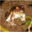

In [3]:
# Carga de datos y validación del primer registro en arreglo.
#--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train[0]

In [4]:
# Preprocesamiento de set de datos
#--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Normalizando set de datos predictivos a [0,1]
#--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
x_train = x_train.astype('float32')/255.00
x_test  = x_test.astype('float32')/255.00

# One-hot variable objetivo (categórica)
#--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
numero_clases = 10
y_train = to_categorical(y_train, numero_clases)
y_test  = to_categorical(y_test, numero_clases)

In [5]:
# Particionamiento del set de datos. (Generando set de validación y Redefiniendo set de training).
#--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
validation_fraction = 0.1
validation_size = int(len(x_train) * validation_fraction)
x_validation, y_validation = x_train[-validation_size:], y_train[-validation_size:]
x_train_final, y_train_final = x_train[:-validation_size], y_train[:-validation_size]

In [6]:
# Definicion de arquitectura para Convolutional Neural Network (CNN)
#--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
cnn_model = Sequential(
    [
      # Primer Bloque.
      Conv2D(32, (3, 3), padding = 'same', activation = 'relu', input_shape = (32, 32, 3)),
      BatchNormalization(),
      Conv2D(32, (3, 3), padding = 'same', activation = 'relu'),
      BatchNormalization(),
      MaxPooling2D((2, 2)),
      Dropout(0.25),

      # Segundo Bloque.
      Conv2D(64, (3, 3), padding = 'same', activation = 'relu'),
      BatchNormalization(),
      Conv2D(64, (3, 3), padding = 'same', activation = 'relu'),
      BatchNormalization(),
      MaxPooling2D((2, 2)),
      Dropout(0.25),

      # Tercer Bloque.
      Conv2D(128, (3, 3), padding = 'same', activation = 'relu'),
      BatchNormalization(),
      Conv2D(128, (3, 3), padding = 'same', activation = 'relu'),
      BatchNormalization(),
      MaxPooling2D((2, 2)),
      Dropout(0.25),

      # Capas Fully Connected.
      Flatten(),
      Dense(256, activation = 'relu'),
      BatchNormalization(),
      Dropout(0.4),
      Dense(numero_clases, activation = 'softmax')
    ]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
# Compilación de modelo cnn_model.
#--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
cnn_model.compile(
    optimizer = Adam(learning_rate = 1e-3),
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

# Generar summary del modelo compilado.
#--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 816,938 (3.12 MB)

 Trainable params: 815,530 (3.11 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [8]:
# Data augmentation
#--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Parámetro para definir el uso de data augmentation.
#--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
use_augmentation = True

In [9]:
# Función para Entrenamiento de Modelo
#--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
def train_model(model, x_training, y_training, x_validation, y_validation, epochs, batch_size, use_augmentation):
  # Evaluar si se debe utilizar data augmentation.
  if (use_augmentation):
    # En caso de usar data augmentation, procesaremos las imagenes según los siguientes parámetros.
    datagen = tf.keras.preprocessing.image.ImageDataGenerator(
        rotation_range = 15,
        width_shift_range = 0.1,
        height_shift_range = 0.1,
        horizontal_flip = True
    )
    datagen.fit(x_training)

  # Entrenamiento.
  #------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
  early_stopping = EarlyStopping(monitor = 'val_accuracy', patience = 10, restore_best_weights = True)

  if (use_augmentation):
    steps_per_epoch = int(np.ceil(len(x_training) / batch_size))

    history = model.fit(
        datagen.flow(x_training, y_training, batch_size = batch_size),
        steps_per_epoch = steps_per_epoch,
        epochs = epochs,
        validation_data = (x_validation, y_validation),
        callbacks = [early_stopping],
        verbose = 1
      )
  else:
    history = model.fit(
      x_training,
      y_training,
      epochs = epochs,
      batch_size = batch_size,
      validation_data = (x_validation, y_validation),
      callbacks = [early_stopping],
      verbose = 1
    )

  return history


In [ ]:
# Llamar funcion train_model para entrenar cnn_model.
#--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Variables de configuración
#--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
var_epochs = 50
var_batch_size = 100
use_augmentation = True

history_global = train_model(cnn_model, x_train, y_train, x_validation, y_validation, var_epochs, var_batch_size, use_augmentation)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


500/500 ━━━━━━━━━━━━━━━━━━━━ 463s 913ms/step - accuracy: 0.3453 - loss: 2.0184 - val_accuracy: 0.4342 - val_loss: 1.5676
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 448s 897ms/step - accuracy: 0.5526 - loss: 1.2487 - val_accuracy: 0.6594 - val_loss: 1.0146
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 442s 884ms/step - accuracy: 0.6344 - loss: 1.0317 - val_accuracy: 0.6860 - val_loss: 0.9023
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 441s 882ms/step - accuracy: 0.6763 - loss: 0.9139 - val_accuracy: 0.7382 - val_loss: 0.7822
Epoch 5/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 436s 873ms/step - accuracy: 0.7088 - loss: 0.8348 - val_accuracy: 0.7652 - val_loss: 0.7012
Epoch 6/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 437s 874ms/step - accuracy: 0.7334 - loss: 0.7733 - val_accuracy: 0.7530 - val_loss: 0.7675
Epoch 7/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 444s 878ms/step - accuracy: 0.7475 - loss: 0.7188 - val_accuracy: 0.7942 - val_loss: 0.6034
Epoch 8/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 437s 875ms/step - accuracy: 0.7623 - loss: 0.68

In [ ]:
# Evaluación del modelo con data test.
#--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
test_loss, test_accuracy = cnn_model.evaluate(x_test, y_test, verbose = 0)
print(f"Test accuracy: {test_accuracy:.4f} %  | Test loss: {test_loss:.4f} % ")

In [ ]:
# Gráficas de curvas de entrenamiento (Loss & Accuracy).
#--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Loss
#--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
plt.figure(figsize = (10, 4))
plt.subplot(1, 2, 1)
plt.plot(history_global.history['loss'], label = 'Training loss')
plt.plot(history_global.history['val_loss'], label = 'Validation loss')
plt.title('Pérdida en Training y Validation')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy
#--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
plt.subplot(1, 2, 2)
plt.plot(history_global.history['accuracy'], label = 'Training accuracy')
plt.plot(history_global.history['val_accuracy'], label = 'Validation accuracy')
plt.title('Precisión en Training y Validation')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()